In [1]:
import joblib
from analysis_utils import *

# Virtualization Settings
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# --- 1. Upload Data ---
df = pd.read_csv("../datasets/bankloan.csv")
print(f"1. Veri Yüklendi. Boyut: {df.shape}")

# --- 1.2. Fixing the Negative Values in Experience Column ---
df["Experience"] = df["Experience"].clip(lower=0)

1. Veri Yüklendi. Boyut: (5000, 14)


In [3]:
# --- 1.3. General Structure ---
check_general_structure(df)

=== Data Types and Non-Null Information ===
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP.Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal.Loan       5000 non-null   int64  
 10  Securities.Account  5000 non-null   int64  
 11  CD.Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB
None

=== Missing Value

,Missing Count,Missing Percentage (%)
ID,0,0.0
Age,0,0.0
Experience,0,0.0
Income,0,0.0
ZIP.Code,0,0.0
Family,0,0.0
CCAvg,0,0.0
Education,0,0.0
Mortgage,0,0.0
Personal.Loan,0,0.0


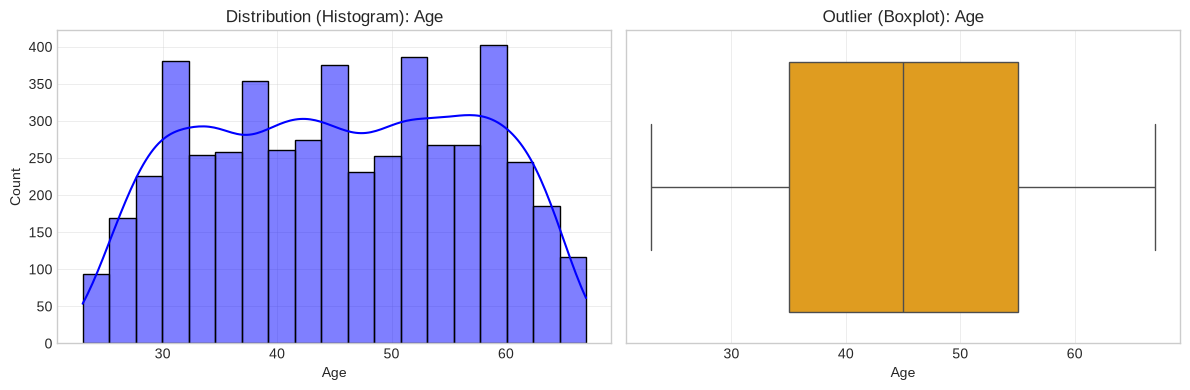

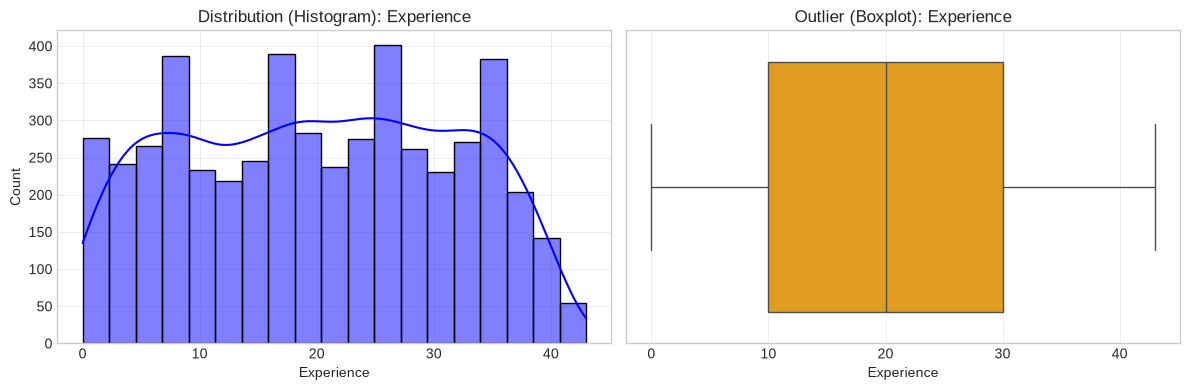

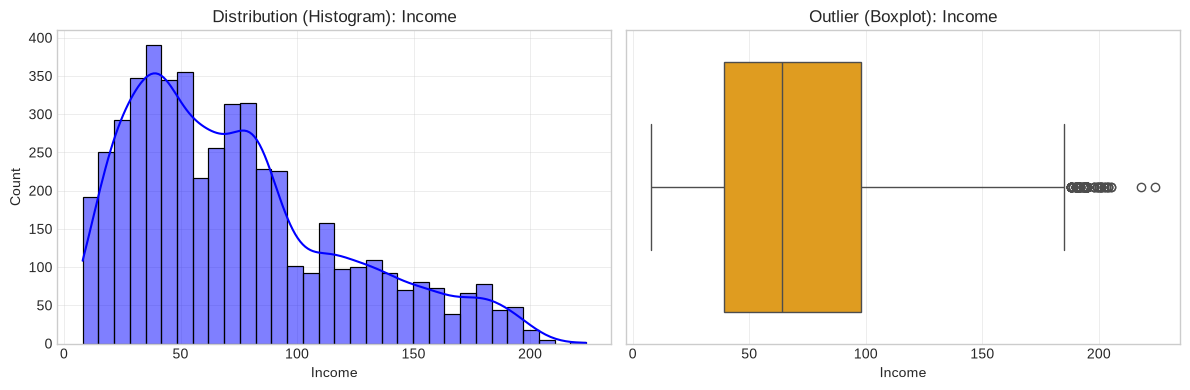

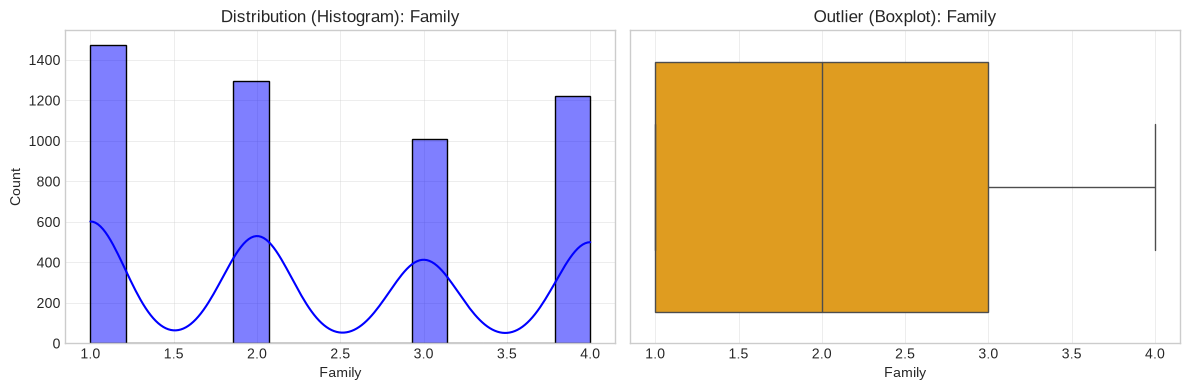

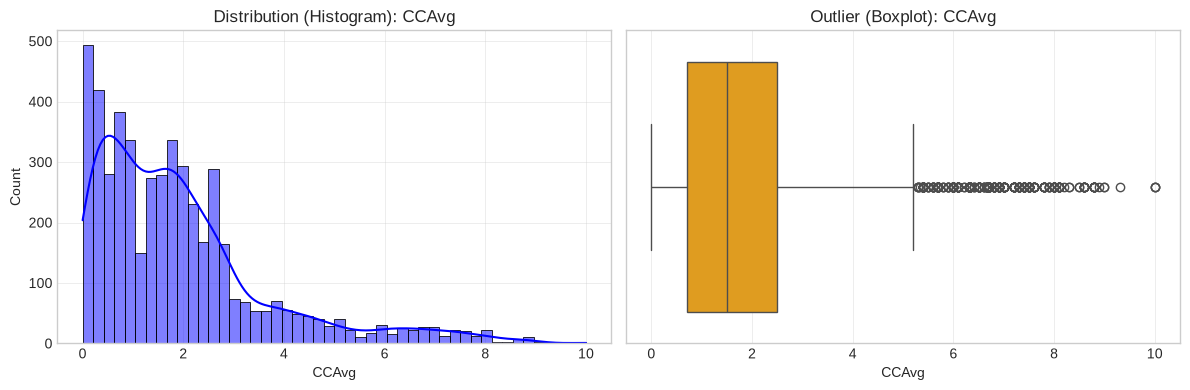

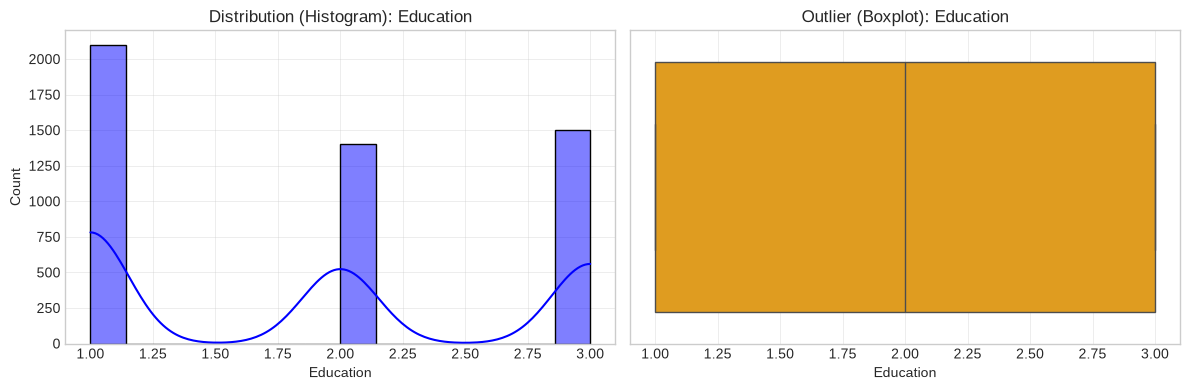

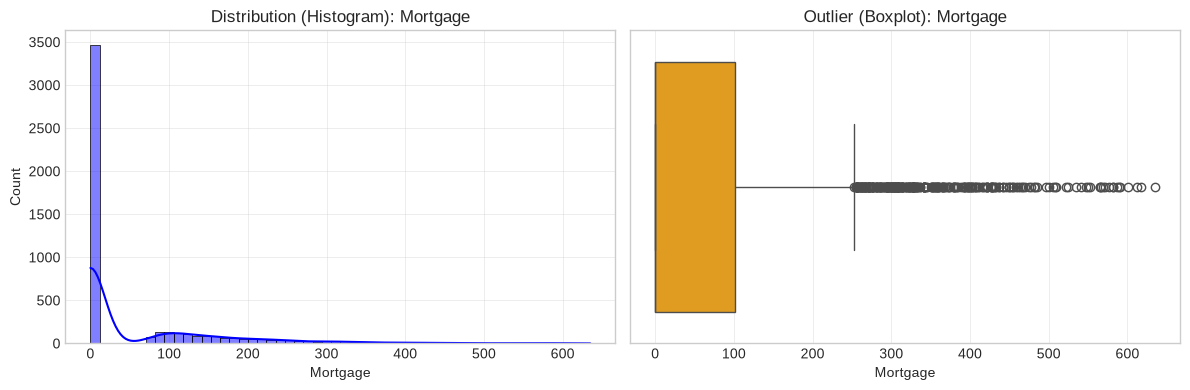

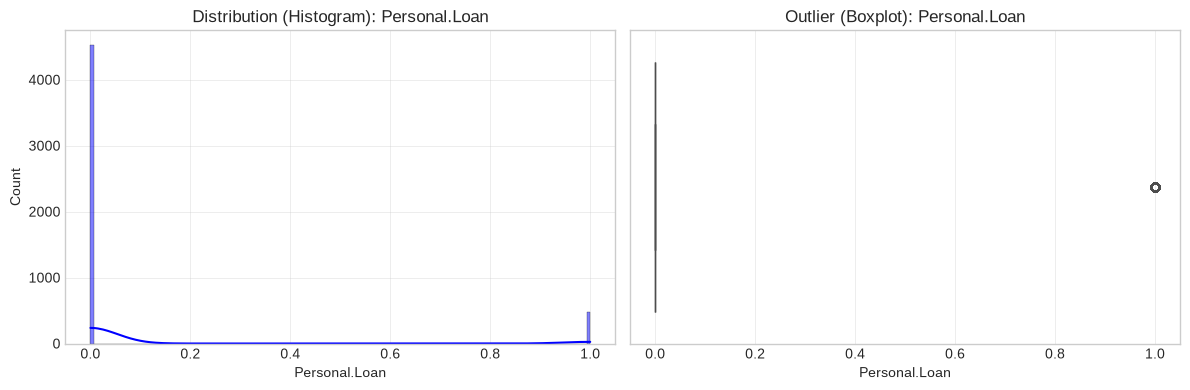

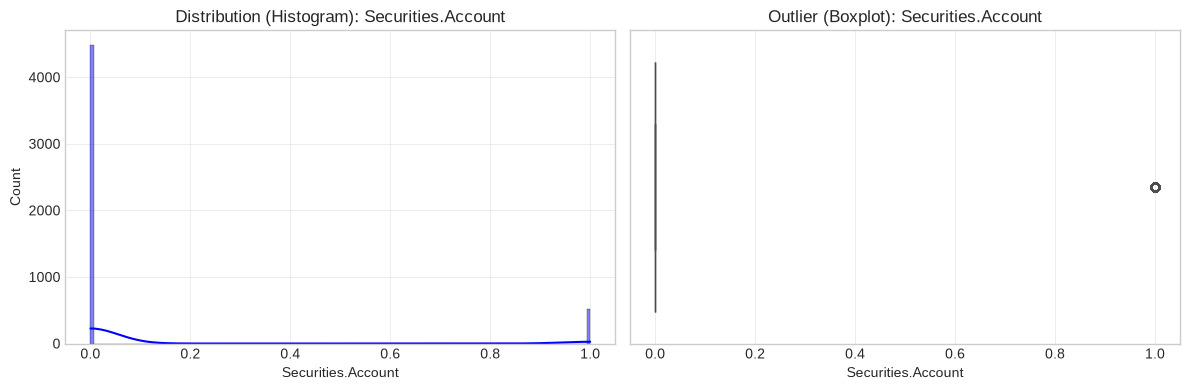

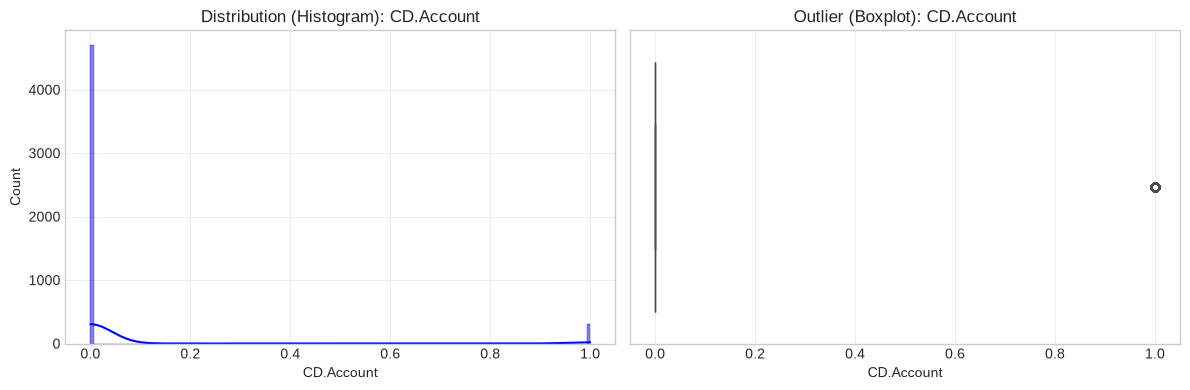

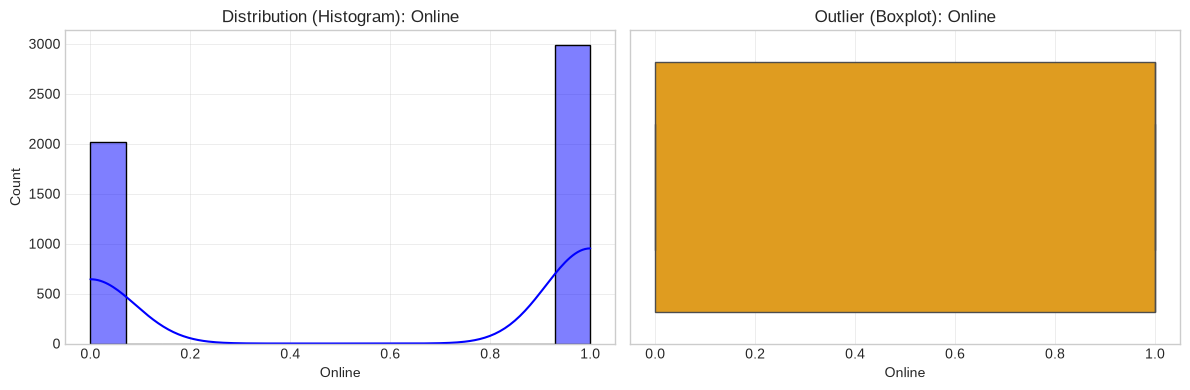

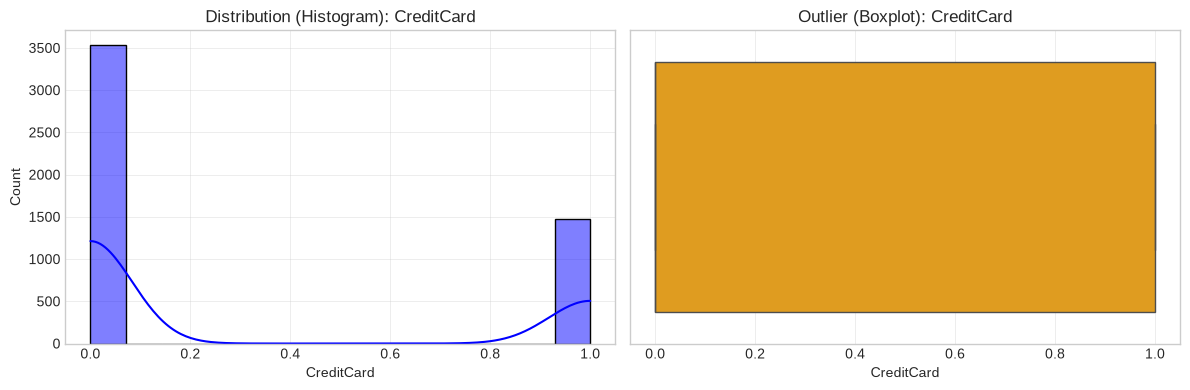

In [4]:
# --- 2. Statistical Distributions ---
# Selecting Necessary Columns
numerical_cols = df.drop(columns=["ID","ZIP.Code"])
plot_statistical_distributions(df, numerical_cols)

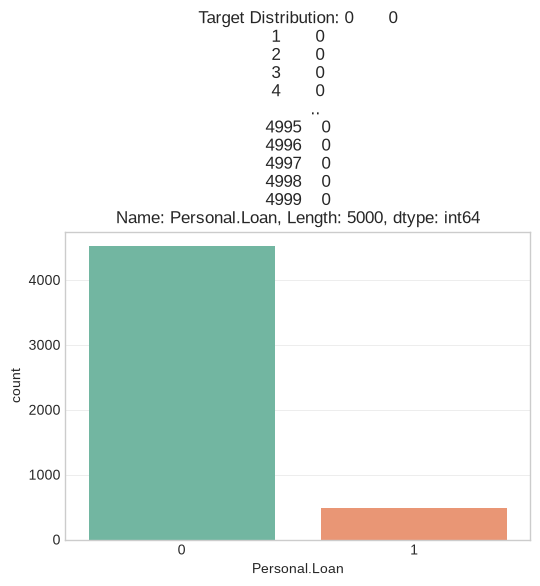

In [5]:
# --- 3. Target Distribution ---
target_column = df["Personal.Loan"]
plot_target_distribution(df, target_column)

=== Correlation Ranking with Target ===
Income                0.502462
CCAvg                 0.366889
CD.Account            0.316355
Mortgage              0.142095
Education             0.136722
Family                0.061367
Securities.Account    0.021954
Online                0.006278
CreditCard            0.002802
ZIP.Code              0.000107
Age                  -0.007726
Experience           -0.007858
ID                   -0.024801
Name: Personal.Loan, dtype: float64
----------------------------------------


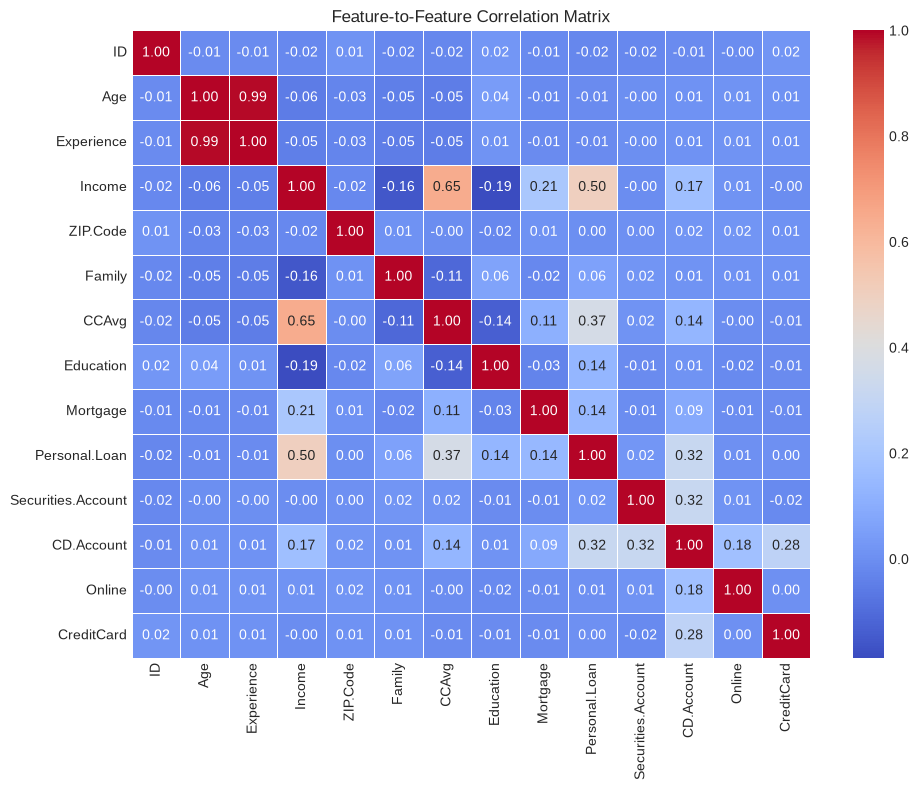

⚠️ Highly correlated (overlapping) features: ['Experience']


In [6]:
# --- 4. Feature Correlations Analyze
target_corr, to_drop = analyze_feature_correlations(df, target_col="Personal.Loan")

In [7]:
# --- 5. Train - Test Split ---
X = df.drop(columns=["Personal.Loan"])
y = df["Personal.Loan"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\n5. Data is Splitted -> Train: {X_train.shape}, Test: {X_test.shape}")


5. Data is Splitted -> Train: (4000, 13), Test: (1000, 13)


In [8]:
# --- 6. Correlation Filter ---
X_train_corr, X_test_corr = correlation_filter(
    X_train, X_test, corr_threshold=0.95
)

9. Remaining Feature Count After Correlation Filter: 12


In [9]:
# --- 7. Clearing Constant Columns ---
constant_cols = [col for col in X_train_corr.columns if X_train_corr[col].nunique() == 0]

if constant_cols:
    print(f"Detected Constant Columns: {constant_cols}")
    X_train_corr = X_train_corr.drop(columns=constant_cols)
    X_test_corr = X_test_corr.drop(columns=constant_cols)
else:
    print("No Constant Columns Detected.")

No Constant Columns Detected.


In [10]:
# --- 8. Feature Selection ---
selected_features = select_best_features_anova(X_train_corr,y_train)
X_train_selected = X_train_corr[selected_features]
X_test_selected = X_test_corr[selected_features]

=== Top 5 Features (ANOVA / SelectKBest) ===
      Feature        Score
2      Income  1313.830547
5       CCAvg   616.649580
9  CD.Account   511.984845
7    Mortgage    80.163695
6   Education    73.720196


In [12]:
# All in Bundle
bundle = {
    "X_train": X_train_selected,
    "X_test": X_test_selected,
    "y_train": y_train,
    "y_test": y_test,
}
# Save to File
joblib.dump(bundle, "../backend/models/bankloan/bankloan_data_bundle.pkl")
print(
    "Processed bankloan datasets are successfully saved to: backend/models/bankloan/"
)

Processed bankloan datasets are successfully saved to: backend/models/bankloan/
